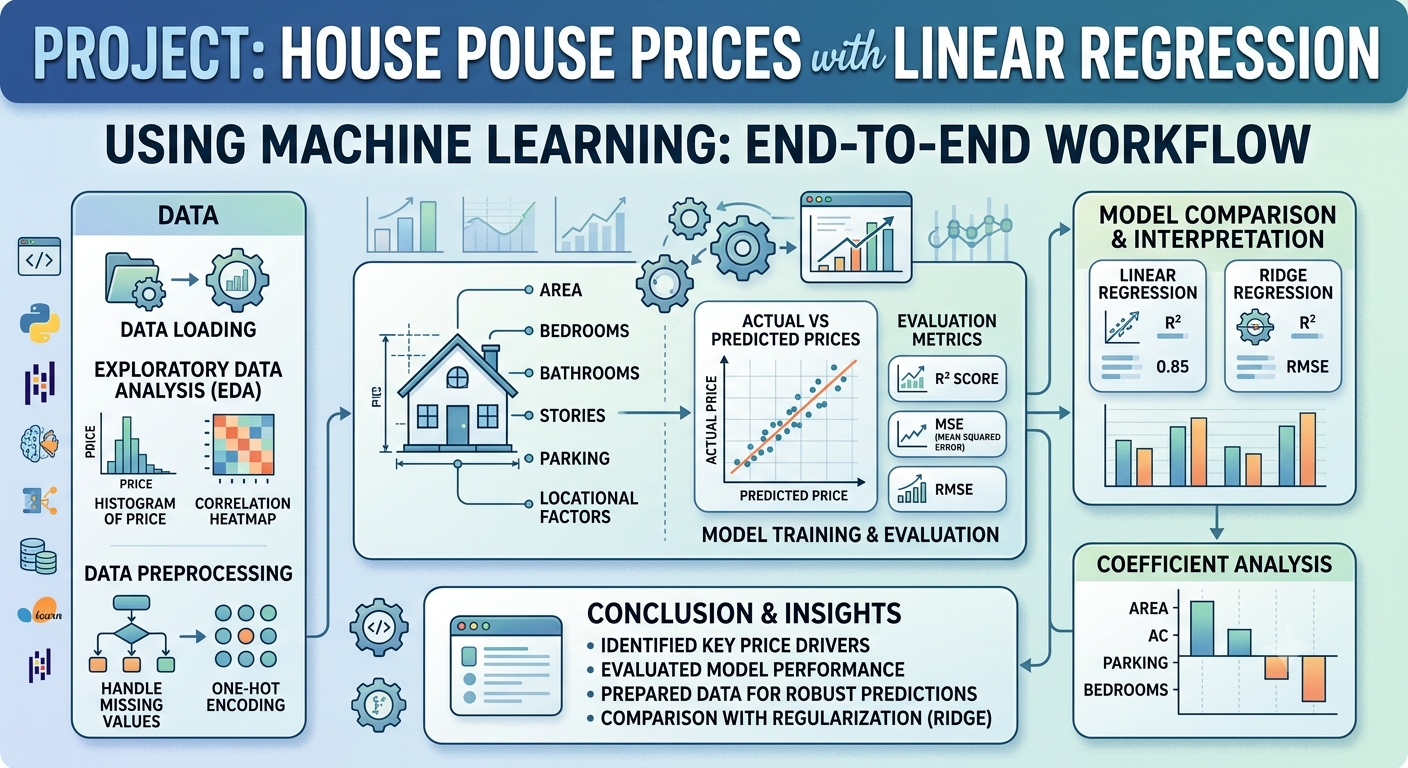

In [21]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

**Loading the Dataset**
The dataset is loaded using Pandas. The first few rows are displayed to understand the structure of the data.

In [23]:
df = pd.read_csv("housing_data.csv")

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


**Dataset Overview**

Before building a machine learning model, it is important to understand the dataset by checking:

Number of rows and columns

Data types

Missing values

Basic statistical summary

In [24]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


**Checking Missing Values**

Missing values can reduce model performance. We first identify whether the dataset contains any missing values.

In [4]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

**Distribution of House Prices**

The distribution of the target variable (Price) helps us understand whether prices are normally distributed or skewed.

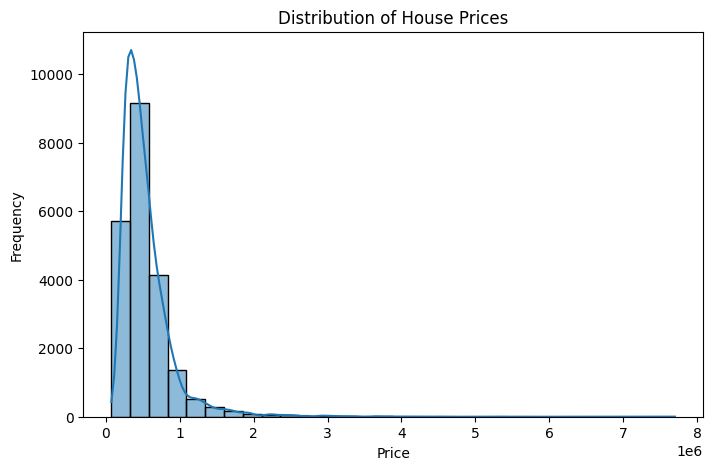

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

**Handling Missing Values**

Numerical missing values are replaced with the median, while categorical missing values are replaced with the most frequent value.

In [26]:
# Fill missing numerical values

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical values

cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

**Correlation Heatmap**

The correlation matrix helps identify which numerical variables are most strongly related to house prices.

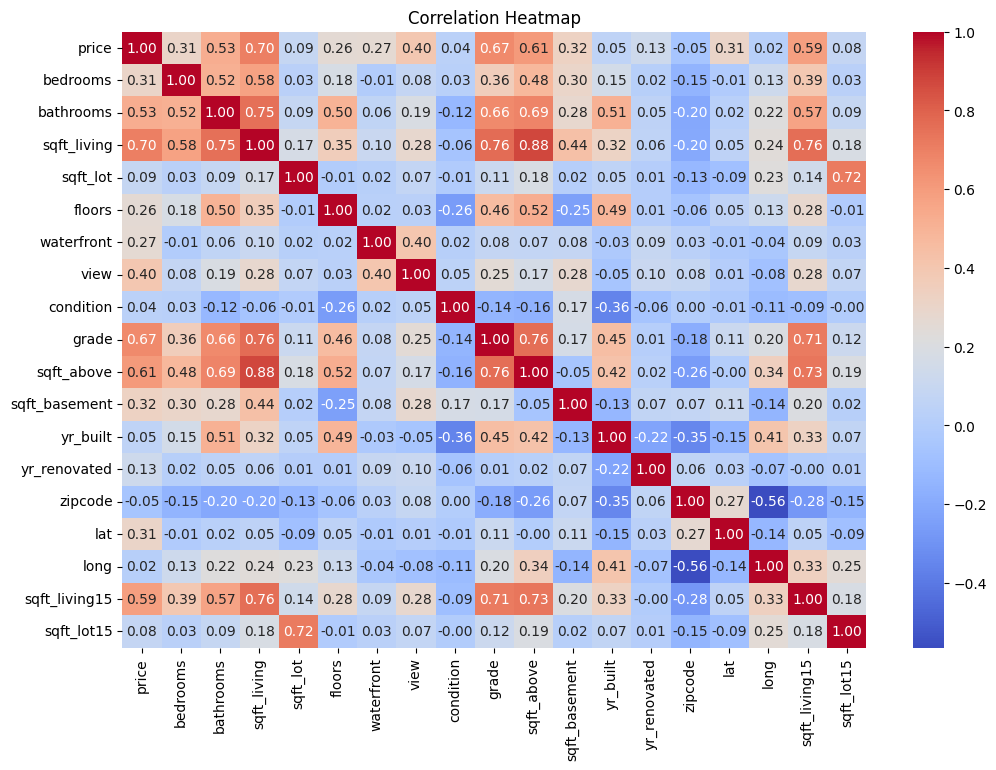

In [27]:
numeric_df = df.drop(["id", "date"], axis=1)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

**Data Preprocessing**

Categorical variables cannot be directly used by Linear Regression. Therefore, One-Hot Encoding is applied to convert categorical variables into numerical format.

In [28]:
# Features and Target

X = df.drop(["id", "date", "price"], axis=1)

y = df["price"]

# Identify categorical and numerical columns
categorical = X.select_dtypes(include="object").columns

numeric = X.select_dtypes(exclude="object").columns

**Train-Test Split**

The dataset is divided into:

80% Training Data

20% Testing Data

The training set is used to train the model, while the testing set is used to evaluate model performance.

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

**Building the Linear Regression Model**

A preprocessing pipeline is created to apply One-Hot Encoding to categorical variables and then train a Linear Regression model.

In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical)
    ],
    remainder="passthrough"
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

**Model Prediction**

In [31]:
y_pred = model.predict(X_test)

**Model Evaluation**

The following evaluation metrics are used:

Mean Squared Error (MSE)

Root Mean Squared Error (RMSE)

R² Score

In [32]:
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MSE :", mse)

print("RMSE :", rmse)

print("R² Score :", r2)

MSE : 45173046132.79194
RMSE : 212539.51663818175
R² Score : 0.7011904448878294


**Actual vs Predicted Prices**

A scatter plot compares the actual house prices with the predicted prices. A model with good performance will have points close to the diagonal line.

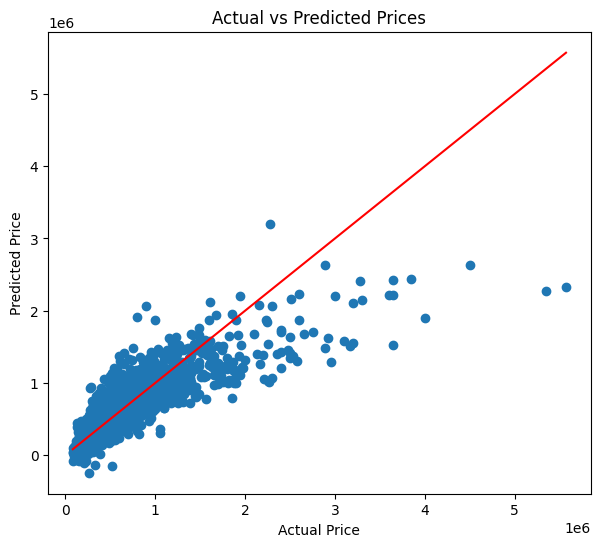

In [33]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

**Residual Plot**

Residuals are the differences between actual and predicted prices. Ideally, they should be randomly distributed around zero with no visible pattern.

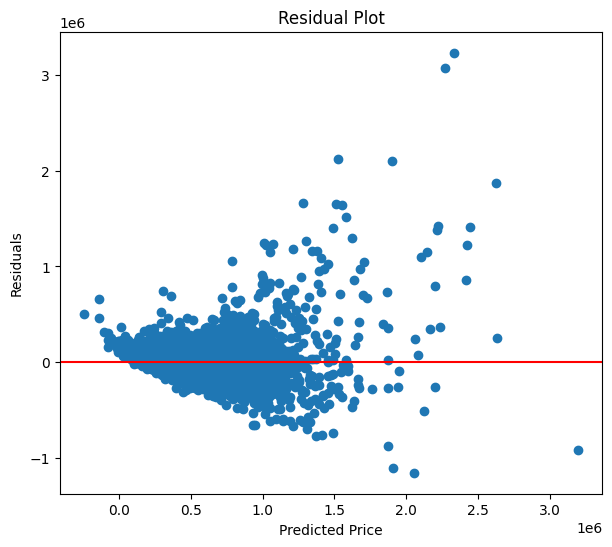

In [34]:
residuals = y_test - y_pred

plt.figure(figsize=(7,6))

plt.scatter(y_pred, residuals)

plt.axhline(0, color='red')

plt.xlabel("Predicted Price")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

**Coefficient Analysis**

The coefficients indicate how each feature affects the predicted house price.

Positive coefficient → increases house price.

Negative coefficient → decreases house price.

In [35]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

coefficients = model.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
14,remainder__lat,595968.122144
5,remainder__waterfront,562413.070005
8,remainder__grade,94567.891697
6,remainder__view,53641.107022
1,remainder__bathrooms,44564.528881
7,remainder__condition,24526.710105
4,remainder__floors,7003.129520
2,remainder__sqft_living,109.015817
9,remainder__sqft_above,70.022741
10,remainder__sqft_basement,38.993076


**Bonus: Ridge Regression**

Ridge Regression is a regularized version of Linear Regression that helps reduce overfitting by penalizing large coefficient values.

In [37]:
ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

ridge_r2 = r2_score(y_test, ridge_pred)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))

print("Ridge RMSE:", ridge_rmse)

print("Ridge R²:", ridge_r2)

Ridge RMSE: 212567.75963992375
Ridge R²: 0.7011110258730537


**Model Comparison**

Both Linear Regression and Ridge Regression models were evaluated to compare their predictive performance.

The evaluation was based on the following metrics:

- Mean Squared Error (MSE): Lower values indicate fewer prediction errors.
- Root Mean Squared Error (RMSE): Lower values indicate better prediction accuracy.
- R² Score: Higher values (closer to 1) indicate that the model explains more variance in the target variable.

The model with the lower RMSE and higher R² Score is considered the better-performing model for predicting house prices.

In [38]:
# Evaluation metrics for Linear Regression
linear_mse = mean_squared_error(y_test, y_pred)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, y_pred)

# Evaluation metrics for Ridge Regression
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

# Create comparison table
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MSE": [linear_mse, ridge_mse],
    "RMSE": [linear_rmse, ridge_rmse],
    "R² Score": [linear_r2, ridge_r2]
})

comparison

,Model,MSE,RMSE,R² Score
0,Linear Regression,4.517305e+10,212539.516638,0.701190
1,Ridge Regression,4.518505e+10,212567.759640,0.701111


**Conclusion**

In this project, a Linear Regression model was developed to predict house prices using various property features. The workflow included data loading, exploratory data analysis (EDA), handling missing values, encoding categorical variables using One-Hot Encoding, correlation analysis, model training, prediction, and performance evaluation.

The model was evaluated using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. Scatter and residual plots were used to visualize prediction accuracy and model performance. Feature coefficients were also analyzed to understand which variables had the greatest positive or negative influence on house prices.

As a bonus, Ridge Regression was implemented and compared with Linear Regression. The comparison helped determine which model generalized better based on RMSE and R² Score.

Overall, this project demonstrates the complete machine learning workflow for a regression problem and provides valuable insights into the factors affecting house prices.